# Análisis de Perfil i Desempeño Professional

**Desafío 1**  
Quin és el perfil sociodemogràfic dels empleats que tenim a l'empresa, i com podem utilitzar aquesta informació per dissenyar polítiques de talent més adaptades a les seves necessitats i potenciar el seu compromís i desenvolupament professional?

*Punts a respondre (dibuix de la pregunta)* 
- Perfil sociodemogràfic (Columnes: 'ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Education', 'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height','BMI_calculated')
- Com podem utilitzar aquesta informació per dissenyar polítiques de talent més adaptades a les seves necessitats i potenciar el seu compromís i desenvolupament professional (valorar les altres variables no demogràfiques (e.g. 'Absenteeism_hours', hit target (comparativa)) o simplement fer-ho de forma teòrica?)

https://chatgpt.com/share/6a1825e0-9ba8-83eb-b635-b41372a59a06

## Librerías

In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Documentos

In [293]:
DATA_INPUT_FILE = '../../Data/clean/clean_data_25052026.csv'

In [294]:
df = pd.read_csv(DATA_INPUT_FILE)

In [295]:
df.sample(5)

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
345,34,23.0,Consulta médica,10.0,Octubre,3,Martes,2,Primavera,118,...,Secundaria,0,0,0,0,83,172,28,28.1,3
688,3,28.0,Consulta dental,11.0,Noviembre,6,Viernes,2,Primavera,179,...,Secundaria,0,1,0,0,89,170,31,30.8,1
26,34,19.0,"Lesiones, intoxicaciones y consecuencias externas",1.0,Enero,2,Lunes,3,Verano,118,...,Secundaria,0,0,0,0,83,172,28,28.1,32
118,33,28.0,Consulta dental,4.0,Abril,6,Viernes,4,Otoño,248,...,Secundaria,2,0,0,1,86,165,32,31.6,8
695,28,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,4,Otoño,225,...,Secundaria,1,0,0,2,69,169,24,24.2,1


In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Reason_absence           697 non-null    float64
 2   Reason_absence_name      697 non-null    object 
 3   Month_absence            737 non-null    float64
 4   Month_absence_name       737 non-null    object 
 5   Day_week                 740 non-null    int64  
 6   Day_week_name            740 non-null    object 
 7   Seasons                  740 non-null    int64  
 8   Seasons_name             740 non-null    object 
 9   Transportation_expense   740 non-null    int64  
 10  Distance_Residence_Work  740 non-null    int64  
 11  Service_time             740 non-null    int64  
 12  Age                      740 non-null    int64  
 13  Work_load_Average_day    740 non-null    float64
 14  Hit_target               7

In [297]:
df.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours'],
      dtype='object')

## Viz

### Perfil sociodemogràfic

In [298]:
perfil_col = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Education', 'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height','BMI_calculated']

In [299]:
df_perfil = df.loc[:, perfil_col]
df_perfil.sample(5)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated
139,11,289,36,13,33,1,Secundaria,2,1,0,1,90,172,30.4
162,24,246,25,16,41,1,Secundaria,0,1,0,0,67,170,23.2
516,34,118,10,10,37,1,Secundaria,0,0,0,0,83,172,28.1
165,20,260,50,11,36,1,Secundaria,4,1,0,0,65,168,23.0
442,34,118,10,10,37,1,Secundaria,0,0,0,0,83,172,28.1


In [300]:
df_perfil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Transportation_expense   740 non-null    int64  
 2   Distance_Residence_Work  740 non-null    int64  
 3   Service_time             740 non-null    int64  
 4   Age                      740 non-null    int64  
 5   Education                740 non-null    int64  
 6   Education_name           740 non-null    object 
 7   Son                      740 non-null    int64  
 8   Social_drinker           740 non-null    int64  
 9   Social_smoker            740 non-null    int64  
 10  Pet                      740 non-null    int64  
 11  Weight                   740 non-null    int64  
 12  Height                   740 non-null    int64  
 13  BMI_calculated           740 non-null    float64
dtypes: float64(1), int64(12), 

In [301]:
df_perfil.duplicated().sum()

np.int64(704)

In [302]:
df_perfil.drop_duplicates(inplace=True)

In [303]:
df_perfil.shape

(36, 14)

In [304]:
df_perfil.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36.0,18.500000,10.535654,1.0,9.75,18.5,27.250,36.0
Transportation_expense,36.0,237.277778,73.982087,118.0,179.00,235.0,289.000,388.0
Distance_Residence_Work,36.0,27.194444,14.520566,5.0,15.00,25.5,37.500,52.0
Service_time,36.0,12.388889,5.309171,1.0,9.00,13.0,14.000,29.0
Age,36.0,38.333333,7.917431,27.0,32.00,37.5,43.000,58.0
Education,36.0,1.361111,0.761682,1.0,1.00,1.0,1.000,4.0
Son,36.0,1.138889,1.018480,0.0,0.00,1.0,2.000,4.0
Social_drinker,36.0,0.527778,0.506309,0.0,0.00,1.0,1.000,1.0
Social_smoker,36.0,0.194444,0.401386,0.0,0.00,0.0,0.000,1.0
Pet,36.0,1.277778,2.092314,0.0,0.00,0.0,2.000,8.0


In [305]:
for col in perfil_col:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-----')

ID
36
[14 36  9 28 11 13 34 22 26 20 10 15 17 24  3 18  7  1 30  5  6  2 31 27
 33 23 21 25 12 32 16 29 19  8  4 35]
-----
Transportation_expense
24
[155 118 228 225 289 369 179 300 260 361 291 246 330 279 235 157 189 388
 184 248 378 268 233 231]
-----
Distance_Residence_Work
25
[12 13 14 26 36 17 10 50 52 31 22 25 51 16  5 11 27 20 29 15 42 49 48 35
 45]
-----
Service_time
18
[14 18 16  9 13 12 10 11  3 17  4  6  7  8  1 29 24 15]
-----
Age
22
[34 50 58 28 33 31 37 30 43 36 40 41 38 39 29 48 27 47 32 49 46 53]
-----
Education
4
[1 3 2 4]
-----
Education_name
4
['Secundaria' 'Posgrado' 'Grado' 'Máster/Doctorado']
-----
Son
5
[2 1 3 0 4]
-----
Social_drinker
2
[1 0]
-----
Social_smoker
2
[0 1]
-----
Pet
6
[0 1 2 4 5 8]
-----
Weight
26
[ 95  98  65  69  90  70  83  56  77  80  73  63  67  89  84  68  88  75
 106  76  58  86  79 108  94 100]
-----
Height
14
[196 178 172 169 171 175 168 170 182 185 167 163 165 174]
-----
BMI_calculated
32
[24.7 30.9 22.  24.2 30.4 24.5 28.1 19.2 25.1 23. 

ID


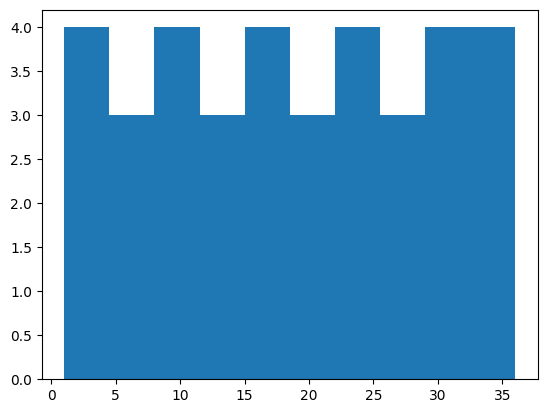

-----
Transportation_expense


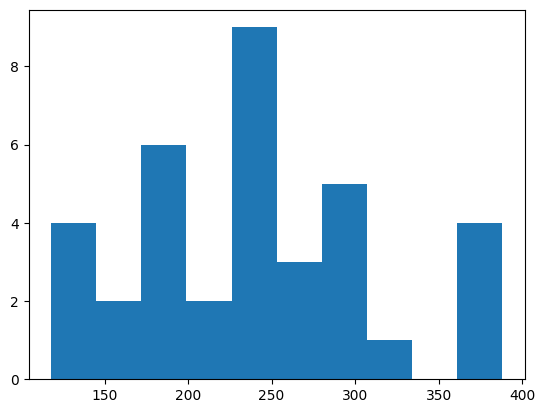

-----
Distance_Residence_Work


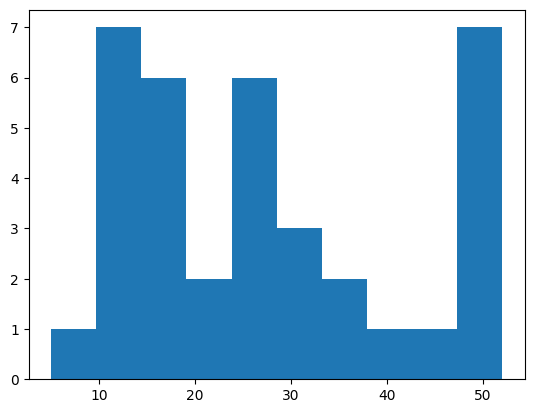

-----
Service_time


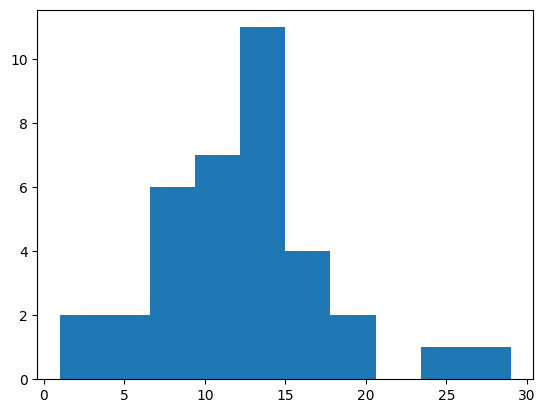

-----
Age


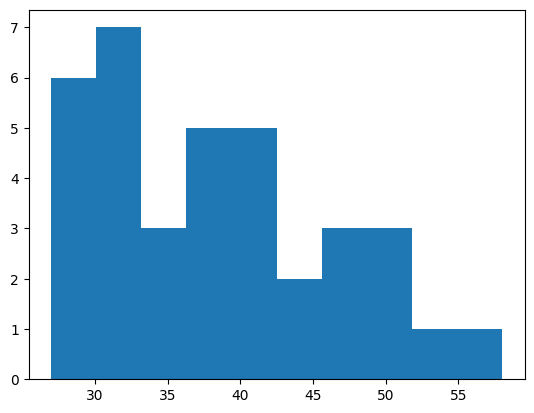

-----
Education


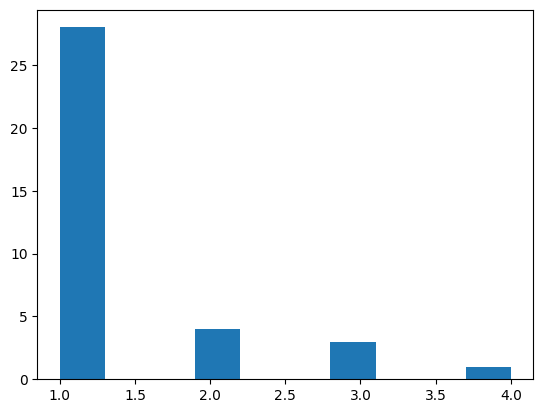

-----
Education_name


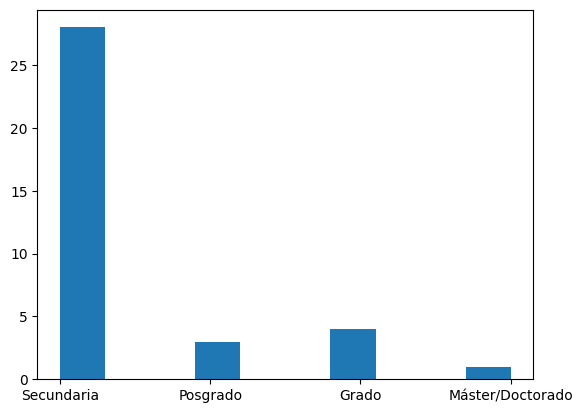

-----
Son


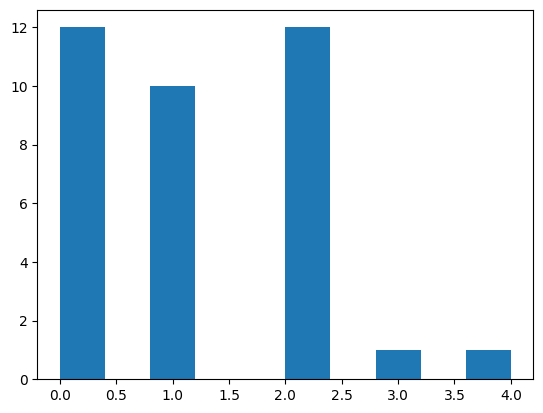

-----
Social_drinker


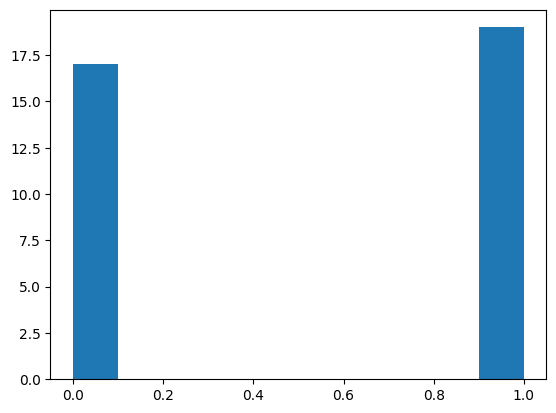

-----
Social_smoker


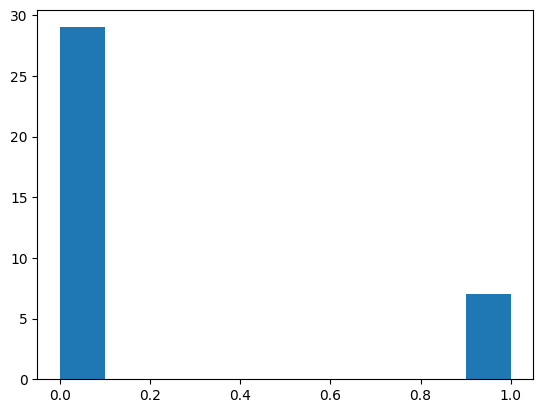

-----
Pet


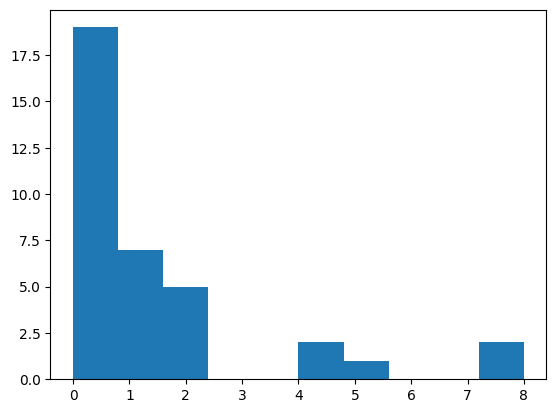

-----
Weight


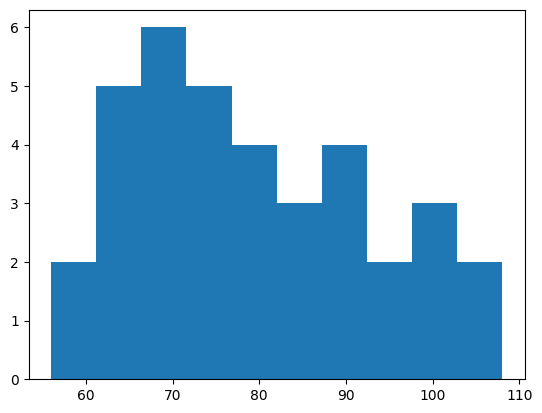

-----
Height


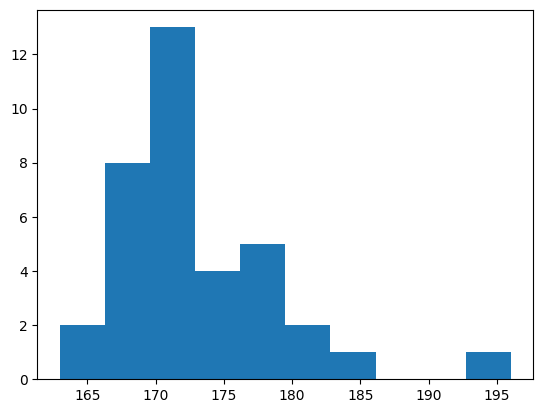

-----
BMI_calculated


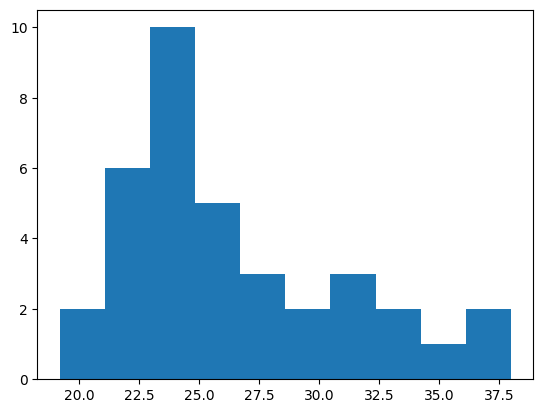

-----


In [306]:
for col in perfil_col:
    print(col)
    plt.hist(df_perfil[col])
    plt.show()
    print('-----')

## PERFIL PROMEDIO DEL TRABAJADOR

In [307]:
df_empleados = df.drop_duplicates(subset='ID').copy()

In [308]:
df_empleados.duplicated().sum()

np.int64(0)

In [309]:
df_empleados.drop_duplicates(inplace=True)

In [310]:
df_empleados.shape

(36, 27)

In [311]:
df_empleados.head(10)

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
0,14,11.0,Sistema digestivo,11.0,Noviembre,2,Lunes,2,Primavera,155,...,Secundaria,2,1,0,0,95,196,25,24.7,120
1,36,13.0,Sistema musculoesquelético,4.0,Abril,4,Miércoles,4,Otoño,118,...,Secundaria,1,1,0,0,98,178,31,30.9,120
2,9,6.0,Sistema nervioso,7.0,Julio,3,Martes,1,Invierno,228,...,Secundaria,2,0,0,1,65,172,22,22.0,120
3,28,9.0,Sistema circulatorio,7.0,Julio,3,Martes,1,Invierno,225,...,Secundaria,1,0,0,2,69,169,24,24.2,112
5,11,19.0,"Lesiones, intoxicaciones y consecuencias externas",3.0,Marzo,2,Lunes,4,Otoño,289,...,Secundaria,2,1,0,1,90,172,30,30.4,104
8,13,13.0,Sistema musculoesquelético,7.0,Julio,2,Lunes,1,Invierno,369,...,Secundaria,3,1,0,0,70,169,25,24.5,80
9,34,19.0,"Lesiones, intoxicaciones y consecuencias externas",12.0,Diciembre,3,Martes,2,Primavera,118,...,Secundaria,0,0,0,0,83,172,28,28.1,64
10,22,1.0,Enfermedades infecciosas y parasitarias,10.0,Octubre,4,Miércoles,2,Primavera,179,...,Posgrado,0,0,0,0,56,171,19,19.2,64
11,26,19.0,"Lesiones, intoxicaciones y consecuencias externas",5.0,Mayo,6,Viernes,4,Otoño,300,...,Secundaria,2,1,1,1,77,175,25,25.1,64
13,20,19.0,"Lesiones, intoxicaciones y consecuencias externas",4.0,Abril,6,Viernes,4,Otoño,260,...,Secundaria,4,1,0,0,65,168,23,23.0,56


In [312]:
perfil_num = [
    'Transportation_expense',
    'Distance_Residence_Work',
    'Service_time',
    'Age',
    'Son',
    'Pet',
    'Weight',
    'Height',
    'BMI_calculated'
]

#Media de variables numéricas
perfil_promedio = df_perfil[perfil_num].mean().round(2)

print("Perfil promedio del empleado:")
print(perfil_promedio)

Perfil promedio del empleado:
Transportation_expense     237.28
Distance_Residence_Work     27.19
Service_time                12.39
Age                         38.33
Son                          1.14
Pet                          1.28
Weight                      78.94
Height                     173.06
BMI_calculated              26.41
dtype: float64


In [313]:
print("=== PERFIL SOCIODEMOGRÁFICO ===")

print("\nEdad media:", df_perfil['Age'].mean().round(1))

print("BMI medio:", df_perfil['BMI_calculated'].mean().round(1))

print("\nEducación más frecuente:")
print(df_perfil['Education_name'].mode()[0])

print("\n% fumadores:")
print((df_perfil['Social_smoker'].mean()*100).round(1), "%")

print("\n% consumen alcohol:")
print((df_perfil['Social_drinker'].mean()*100).round(1), "%")

=== PERFIL SOCIODEMOGRÁFICO ===

Edad media: 38.3
BMI medio: 26.4

Educación más frecuente:
Secundaria

% fumadores:
19.4 %

% consumen alcohol:
52.8 %


## 1. ANALISIS RESPECTO ABSENTISMO

### Barras Absentismo

In [314]:
def comparar_absentismo(df, variable):
    resultado = (
        df.groupby(variable)['Absenteeism_hours']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='Absenteeism_hours', ascending=False)
    )

    conteo = df[variable].value_counts()

    print("\n Recuento por grupo:")
    print(conteo)

    print("\n Absentismo medio por grupo:")
    print(resultado)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=resultado,
        x=variable,
        y='Absenteeism_hours'
    )

    plt.title(f'Absentismo medio por {variable}')
    plt.ylabel('Horas promedio absentismo')
    plt.xlabel(variable)

    plt.xticks(rotation=45)

    plt.show()


 Recuento por grupo:
Education_name
Secundaria          28
Grado                4
Posgrado             3
Máster/Doctorado     1
Name: count, dtype: int64

 Absentismo medio por grupo:
     Education_name  Absenteeism_hours
3        Secundaria              39.57
2          Posgrado              29.33
0             Grado              20.00
1  Máster/Doctorado               8.00


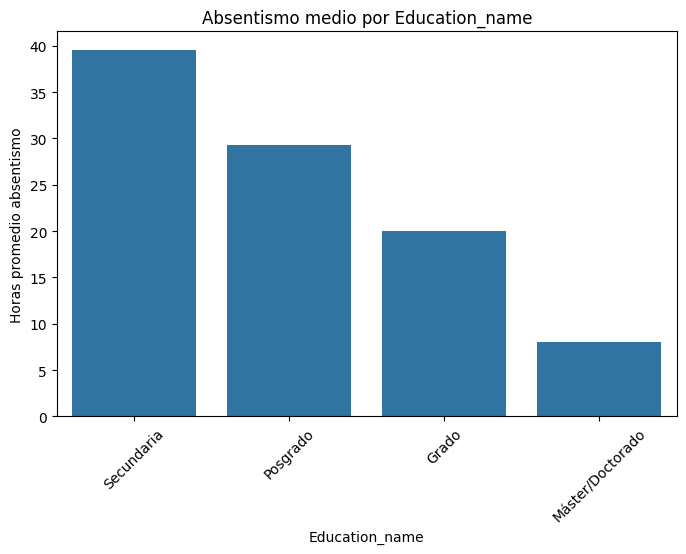

In [315]:
comparar_absentismo(df_empleados, 'Education_name')


 Recuento por grupo:
Social_smoker
0    29
1     7
Name: count, dtype: int64

 Absentismo medio por grupo:
   Social_smoker  Absenteeism_hours
0              0              38.76
1              1              22.86


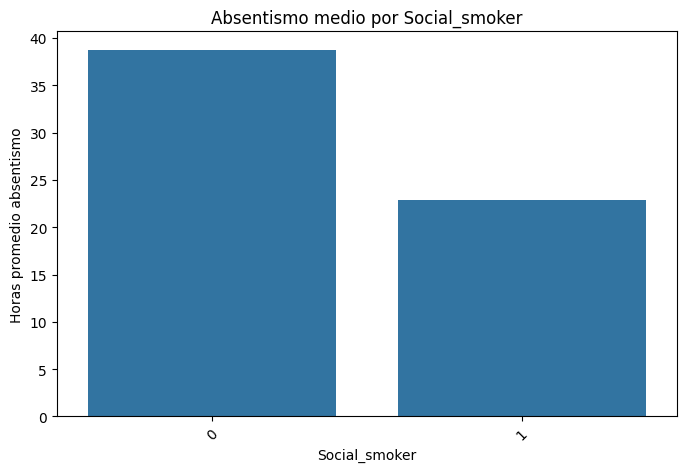

In [316]:
comparar_absentismo(df_empleados, 'Social_smoker')


 Recuento por grupo:
Social_drinker
1    19
0    17
Name: count, dtype: int64

 Absentismo medio por grupo:
   Social_drinker  Absenteeism_hours
1               1              40.21
0               0              30.59


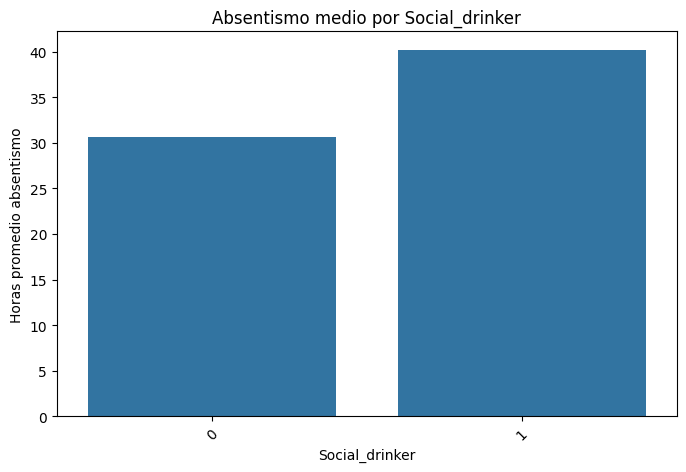

In [317]:
comparar_absentismo(df_empleados, 'Social_drinker')


 Recuento por grupo:
Son
2    12
0    12
1    10
3     1
4     1
Name: count, dtype: int64

 Absentismo medio por grupo:
   Son  Absenteeism_hours
3    3              80.00
4    4              56.00
2    2              42.67
1    1              36.00
0    0              23.00


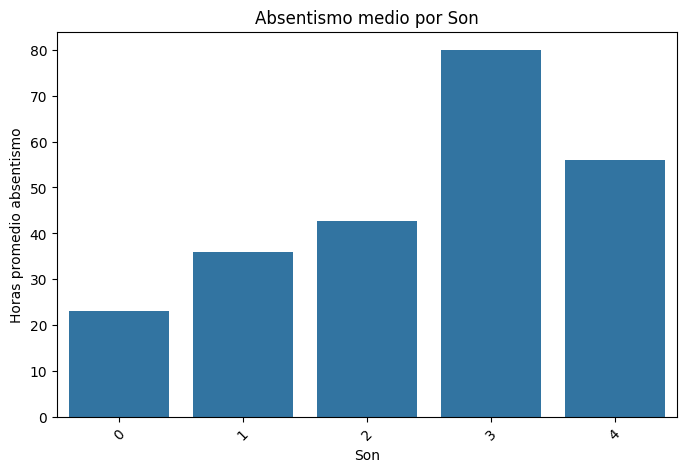

In [318]:
comparar_absentismo(df_empleados, 'Son')

### Distancia al trabajo vs absentismo

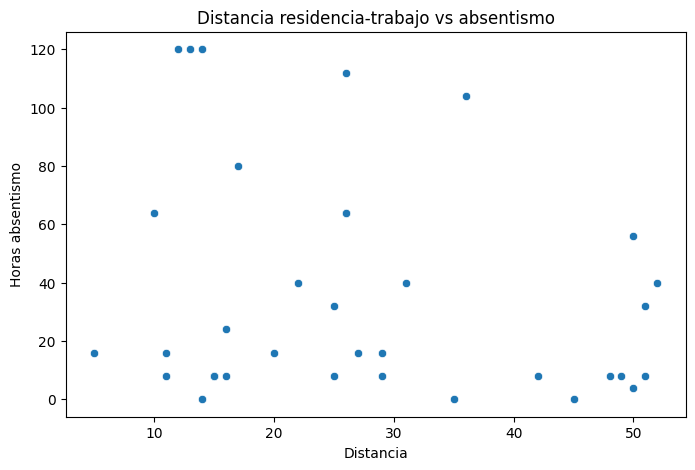

In [319]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_empleados,
    x='Distance_Residence_Work',
    y='Absenteeism_hours'
)

plt.title('Distancia residencia-trabajo vs absentismo')
plt.xlabel('Distancia')
plt.ylabel('Horas absentismo')

plt.show()

### Edad vs Absentismo - Boxplot

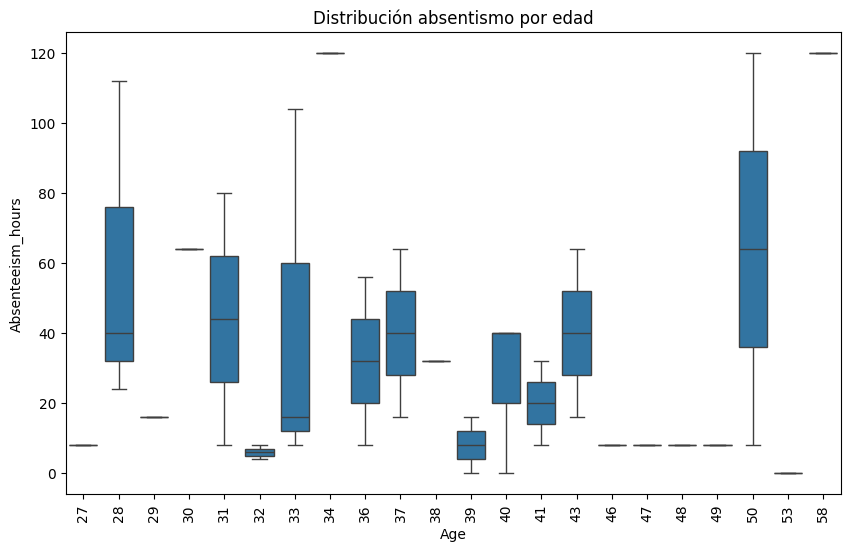

In [320]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_empleados,
    x='Age',
    y='Absenteeism_hours'
)

plt.title('Distribución absentismo por edad')

plt.xticks(rotation=90)

plt.show()

### Heatmap correlaciones

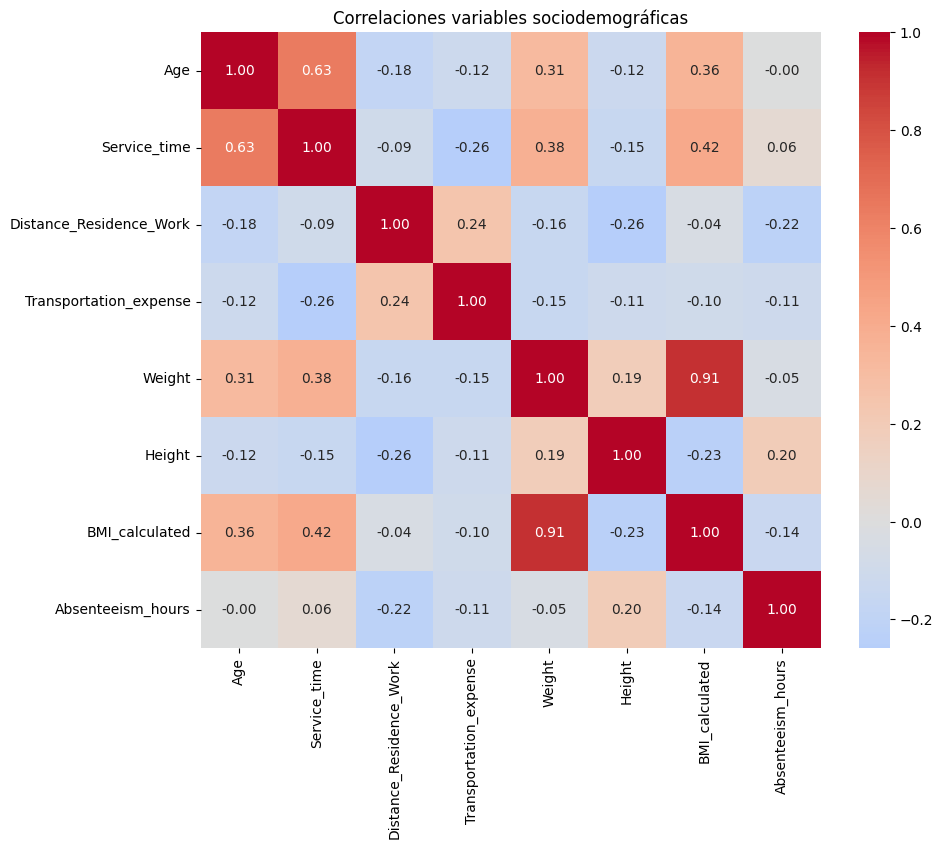

In [337]:
variables_corr = [
    'Age',
    'Service_time',
    'Distance_Residence_Work',
    'Transportation_expense',
    'Weight',
    'Height',
    'BMI_calculated',
    'Absenteeism_hours'
]

corr = df_empleados[variables_corr].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlaciones variables sociodemográficas')
plt.show()

    Interpretación:

1. Relaciones esperadas y consistentes

* **Peso y BMI (0.91)**: correlación muy alta y lógica, ya que el BMI depende directamente del peso y la altura, lo que valida la coherencia de los datos.

* **Edad y antigüedad (0.63)**: relación positiva clara, indicando que los empleados de mayor edad suelen tener más tiempo en la empresa, reflejando una plantilla progresivamente estable.


2. Patrones sociodemográficos relevantes

* **Edad / antigüedad y BMI (0.36–0.42)**: correlaciones moderadas que sugieren una posible tendencia a mayor índice de masa corporal en empleados de mayor edad o con más años en la empresa, lo que abre la puerta a políticas de bienestar y salud preventiva.

* **Distancia y gasto de transporte (0.24)**: relación débil, lo que indica que el coste de transporte no depende exclusivamente de la distancia, sino también de otros factores como el medio utilizado.


3. Relación con el absentismo

* El absentismo muestra **correlaciones muy débiles con casi todas las variables**.

* **Distancia (-0.22)**: relación negativa débil, indicando que vivir más lejos no implica necesariamente más absentismo.

* **Edad (0.00) y antigüedad (0.06)**: prácticamente sin relación lineal con las horas de ausencia.


    Conclusión general

El análisis sugiere que el absentismo no puede explicarse mediante relaciones lineales simples con variables individuales como edad, peso o distancia. Es necesario un analisis clustering

### Edad de fumadores/no fumadores

In [322]:
df_empleados.groupby('Social_smoker')[['Age', 'BMI_calculated', 'Absenteeism_hours']].mean().round(2)

,Age,BMI_calculated,Absenteeism_hours
Social_smoker,,,
0,37.90,26.85,38.76
1,40.14,24.57,22.86


### Edad de consumen/no consumen alcohol

In [323]:
df_empleados.groupby('Social_drinker')[['Age', 'BMI_calculated', 'Absenteeism_hours']].mean().round(2)

,Age,BMI_calculated,Absenteeism_hours
Social_drinker,,,
0,39.18,25.66,30.59
1,37.58,27.07,40.21


### Segmentación perfiles por edad

In [324]:
def clasificar_edad(edad):

    if edad < 30:
        return 'Joven'
    
    elif edad < 45:
        return 'Adulto'
    
    else:
        return 'Senior'


df_empleados['Perfil_edad'] = df_empleados['Age'].apply(clasificar_edad)


 Recuento por grupo:
Perfil_edad
Adulto    23
Senior     8
Joven      5
Name: count, dtype: int64

 Absentismo medio por grupo:
  Perfil_edad  Absenteeism_hours
1       Joven              40.00
2      Senior              35.00
0      Adulto              34.96


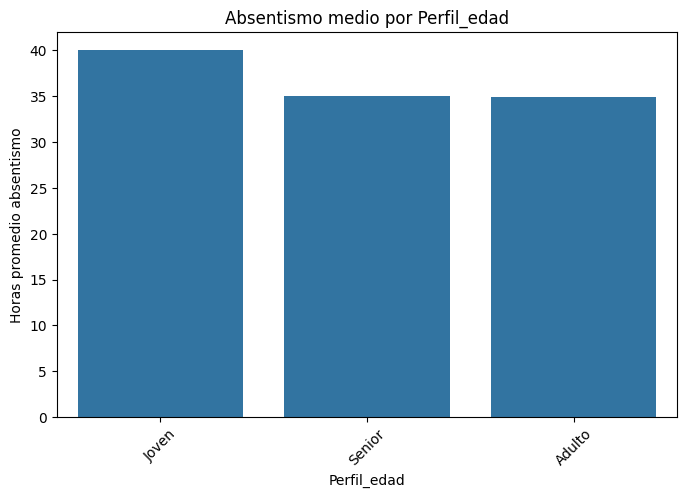

In [325]:
comparar_absentismo(df_empleados, 'Perfil_edad')

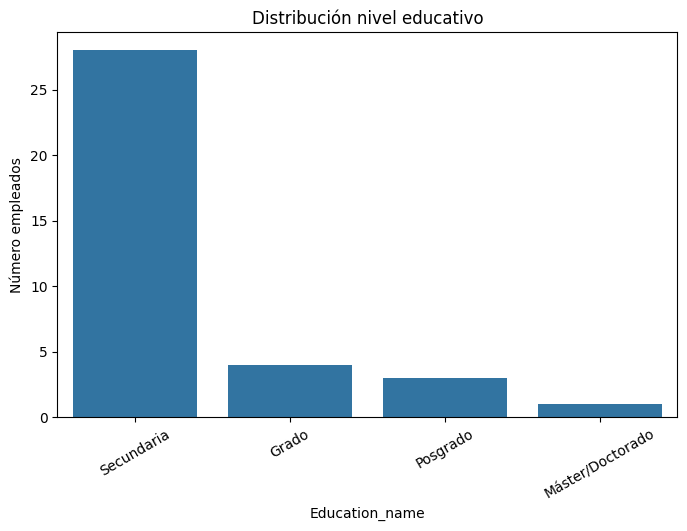

In [327]:
educacion = df_empleados['Education_name'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=educacion.index,
    y=educacion.values
)

plt.title('Distribución nivel educativo')
plt.ylabel('Número empleados')

plt.xticks(rotation=30)

plt.show()

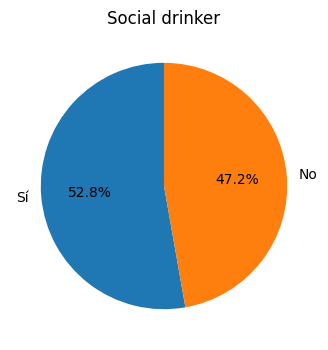

In [328]:
drinker = df_empleados['Social_drinker'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    drinker.values,
    labels=['Sí', 'No'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Social drinker')

plt.show()

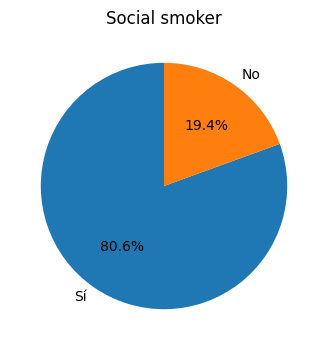

In [329]:
smoker = df_empleados['Social_smoker'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    smoker.values,
    labels=['Sí', 'No'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Social smoker')

plt.show()

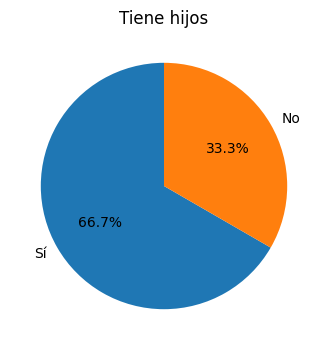

In [330]:
df_empleados['Has_children'] = df_empleados['Son'].apply(lambda x: 'Sí' if x > 0 else 'No')

children = df_empleados['Has_children'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    children.values,
    labels=children.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Tiene hijos')
plt.show()

plt.show()

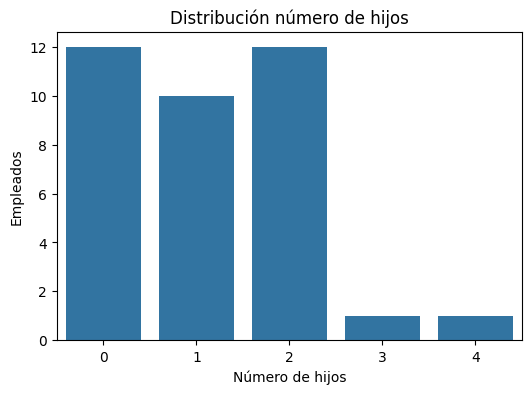

In [331]:
sons = df_empleados['Son'].value_counts().sort_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x=sons.index,
    y=sons.values
)

plt.title('Distribución número de hijos')
plt.xlabel('Número de hijos')
plt.ylabel('Empleados')

plt.show()

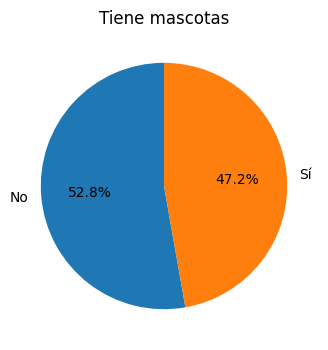

In [332]:
df_empleados['Has_pet'] = df_empleados['Pet'].apply(lambda x: 'Sí' if x > 0 else 'No')

pets = df_empleados['Has_pet'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    pets.values,
    labels=pets.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Tiene mascotas')
plt.show()

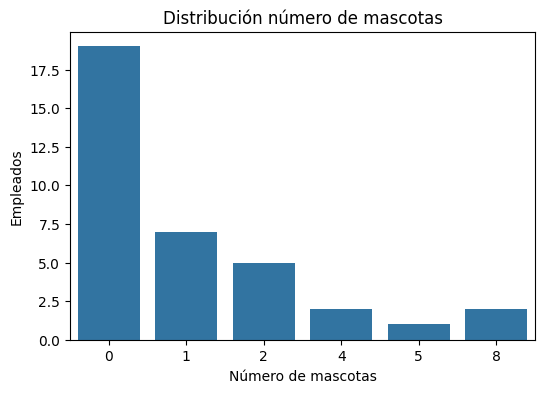

In [333]:
pets = df_empleados['Pet'].value_counts().sort_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x=pets.index,
    y=pets.values
)

plt.title('Distribución número de mascotas')
plt.xlabel('Número de mascotas')
plt.ylabel('Empleados')

plt.show()

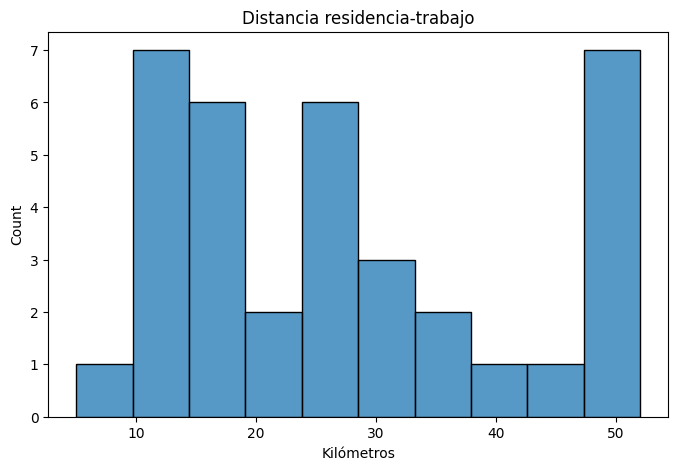

In [334]:
plt.figure(figsize=(8,5))

sns.histplot(df_empleados['Distance_Residence_Work'], bins=10)

plt.title('Distancia residencia-trabajo')
plt.xlabel('Kilómetros')

plt.show()

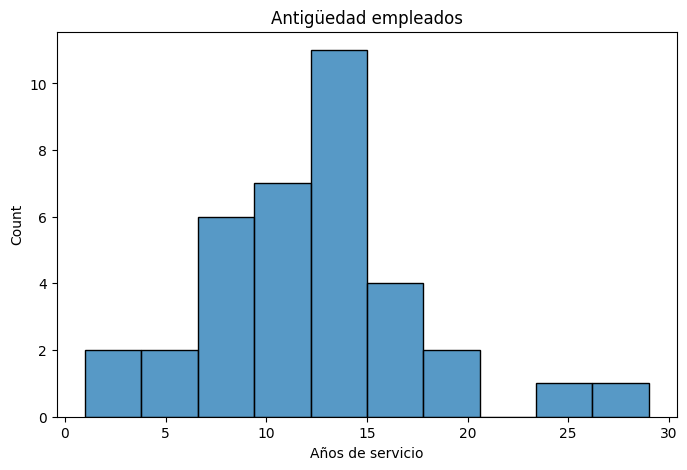

In [335]:
plt.figure(figsize=(8,5))

sns.histplot(df_empleados['Service_time'], bins=10)

plt.title('Antigüedad empleados')
plt.xlabel('Años de servicio')

plt.show()

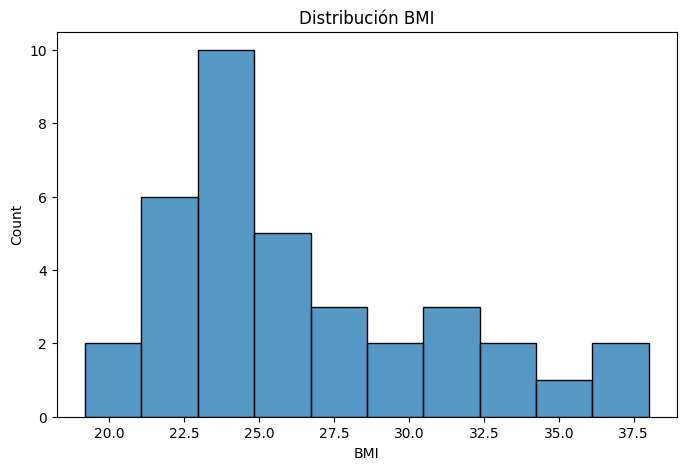

In [336]:
plt.figure(figsize=(8,5))

sns.histplot(df_empleados['BMI_calculated'], bins=10)

plt.title('Distribución BMI')
plt.xlabel('BMI')

plt.show()